# RL - Chapter 7 - N-step TD - Windy Gridworld

Includes:

- Sarsa


In [335]:
from toc import generate_toc

path = 'ch_7_ns_TD_p2_windy_gridworld.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 7 - N-step TD - Windy Gridworld](#rl-chapter-7-n-step-td-windy-gridworld)
  - [Windy Gridworld environment](#windy-gridworld-environment)
  - [N-step Sarsa](#n-step-sarsa)
  - [result](#result)

In [336]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)

In [337]:
def argmax_random_tie(values: np.ndarray) -> int:
    values = np.asarray(values)
    max_value = np.max(values)
    candidates = np.flatnonzero(values == max_value)
    try:
        return np.random.choice(candidates)
    except ValueError:
        print("Values:", values)
        print("Max value:", max_value)
        print("Candidates:", candidates)
        raise

## Windy Gridworld environment


In [338]:
# Windy Gridworld environment
class WindyGridworld:
    def __init__(self):
        self.y_max = 7
        self.x_max = 10
        self.start_state = (0, 3)
        self.goal_state = (7, 3)
        # wind strength for each column
        self.wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
        # action space: up, down, left, right
        actions = [(x, y) for x in range(-1, 2) for y in range(-1, 2)]  # if abs(x) + abs(y) != 0
        self.actions = actions
        # self.actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]
        self.n_actions = len(self.actions)

## N-step Sarsa

On Policy and On policy


In [339]:
class NstepSarsa:
    def __init__(self, env: WindyGridworld, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=100, n=5, excepted_sarsa=False):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.behavior_epsilon = 0.2  # more exploratory behavior policy for off-policy learning
        self.n = n
        self.excepted_sarsa = excepted_sarsa
        self.n_episodes = n_episodes
        self.n_steps_per_episode = []
        # initialize Q-values to zero
        # self.Q = defaultdict(lambda: np.zeros(self.env.n_actions))
        # random initialization of Q-values to encourage exploration
        self.Q = defaultdict(lambda: np.random.rand(self.env.n_actions))
        self.Q[self.env.goal_state] = np.zeros(self.env.n_actions)  # Q-values for goal state are zero

    def run_off_policy(self):
        for episode in range(self.n_episodes):
            state = self.env.start_state
            action, p_b = self.behavior_policy(state)
            states = [state]
            actions = [action]
            rewards = [0]  # reward for time step 0 is 0
            rho = [self.rho_action(state, action, p_b)]
            t = 0
            T = float('inf')
            while True:
                if t < T:
                    next_state, reward, done = self.step(states[-1], action)
                    states.append(next_state)
                    rewards.append(reward)
                    if done:
                        T = t + 1
                    else:
                        action, p_b = self.behavior_policy(next_state)
                        actions.append(action)
                        rho.append(self.rho_action(next_state, action, p_b))
                tau = t - self.n + 1
                if tau >= 0:
                    G = sum(self.gamma ** (i - tau - 1) * rewards[i] for i in range(tau + 1, min(tau + self.n, T) + 1))
                    # prevent overflow in importance sampling ratio by capping it at a reasonable value (e.g., 10)
                    RHO = np.prod(rho[tau + 1:min(tau + self.n, T)])
                    # print(f"Episode {episode}, time {t}, tau {tau}, G {G:.2f}, RHO {RHO:.2f}")
                    if (tau + self.n) < T:
                        if self.excepted_sarsa:
                            expected_Q = np.dot(self.Q[states[tau + self.n]], self.get_greedy_action_probabilities(states[tau + self.n]))
                            G += self.gamma ** self.n * expected_Q
                        else:
                            G += self.gamma ** self.n * self.Q[states[tau + self.n]][actions[tau + self.n]]
                    state_tau = states[tau]
                    action_tau = actions[tau]
                    # update Q-value
                    self.Q[state_tau][action_tau] += self.alpha * RHO * (G - self.Q[state_tau][action_tau])
                if tau == T - 1:
                    break
                t += 1
            self.n_steps_per_episode.append(t)

    def run_on_policy(self):
        for episode in range(self.n_episodes):
            state = self.env.start_state
            action, _ = self.greedy_policy(state)
            states = [state]
            actions = [action]
            rewards = [0]  # reward for time step 0 is 0
            t = 0
            T = float('inf')
            while True:
                if t < T:
                    next_state, reward, done = self.step(states[-1], actions[-1])
                    states.append(next_state)
                    rewards.append(reward)
                    if done:
                        T = t + 1
                    else:
                        next_action, _ = self.greedy_policy(next_state)
                        actions.append(next_action)
                tau = t - self.n + 1
                if tau >= 0:
                    G = sum(self.gamma ** (i - tau - 1) * rewards[i] for i in range(tau + 1, min(tau + self.n, T) + 1))
                    if (tau + self.n) < T:
                        if self.excepted_sarsa:
                            expected_Q = np.dot(self.Q[states[tau + self.n]], self.get_greedy_action_probabilities(states[tau + self.n]))
                            G += self.gamma ** self.n * expected_Q
                        else:
                            G += self.gamma ** self.n * self.Q[states[tau + self.n]][actions[tau + self.n]]
                    state_tau = states[tau]
                    action_tau = actions[tau]
                    # update Q-value
                    self.Q[state_tau][action_tau] += self.alpha * (G - self.Q[state_tau][action_tau])
                if tau == T - 1:
                    break
                t += 1
            self.n_steps_per_episode.append(t)

    def step(self, state, action):
        '''take action and return next state, reward, and done flag'''
        x, y = state
        dx, dy = self.env.actions[action]
        wind_strength = self.env.wind[x]
        x += dx
        y += dy
        y += wind_strength
        # keep within grid boundaries
        x = max(0, min(self.env.x_max - 1, x))
        y = max(0, min(self.env.y_max - 1, y))
        next_state = (x, y)
        done = next_state == self.env.goal_state
        reward = 0 if done else -1
        return next_state, reward, done

    def greedy_policy(self, state):
        '''epsilon-greedy action selection '''
        p_other = self.epsilon / self.env.n_actions
        p_best = 1 - self.epsilon + p_other
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.env.n_actions), p_other
        else:
            return argmax_random_tie(self.Q[state]), p_best

    def behavior_policy(self, state):
        p_other = self.behavior_epsilon / self.env.n_actions
        p_best = 1 - self.behavior_epsilon + p_other
        if np.random.rand() < self.behavior_epsilon:
            return np.random.choice(self.env.n_actions), p_other
        else:
            return argmax_random_tie(self.Q[state]), p_best

    def get_greedy_action_probabilities(self, state):
        '''get action probabilities for epsilon-greedy policy'''
        action_probabilities = np.ones(self.env.n_actions) * self.epsilon / self.env.n_actions
        best_action = argmax_random_tie(self.Q[state])
        action_probabilities[best_action] += (1.0 - self.epsilon)
        return action_probabilities

    def rho_action(self, state, action, p_b):
        '''calculate importance sampling ratio for given state and action'''
        target_probabilities = self.get_greedy_action_probabilities(state)
        p_t = target_probabilities[action]
        rho = p_t / (p_b + 1e-8)  # add small constant to avoid division by zero
        rho = min(max(rho, 0), 10)  # cap rho to prevent extreme values
        return rho

## result


In [340]:
# run On Policy N step Sarsa
env = WindyGridworld()
sarsa_on_policy = NstepSarsa(env, gamma=1.0, alpha=0.1, n_episodes=500, n=4, epsilon=0.1, excepted_sarsa=True)
sarsa_on_policy.run_on_policy()

In [341]:
# run Off Policy N step Sarsa
env = WindyGridworld()
sarsa_off_policy = NstepSarsa(env, gamma=1.0, alpha=0.1, n_episodes=500, n=4, epsilon=0.1, excepted_sarsa=True)
sarsa_off_policy.run_off_policy()

In [342]:
# find path from start to goal using learned policy
def find_path(env: WindyGridworld, Q):
    state = env.start_state
    path = [state]
    while state != env.goal_state:
        action = np.argmax(Q[state])
        dx, dy = env.actions[action]
        x, y = state
        wind_strength = env.wind[x]
        x += dx
        y += dy
        y += wind_strength
        # keep within grid boundaries
        x = max(0, min(env.x_max - 1, x))
        y = max(0, min(env.y_max - 1, y))
        state = (x, y)
        path.append(state)
        if len(path) > 100:
            print("Policy did not reach goal within 100 steps.")
            break
    return path

In [343]:
# find path on policy
path_on_policy = find_path(env, sarsa_on_policy.Q)

In [344]:
# find path off policy
path_off_policy = find_path(env, sarsa_off_policy.Q)

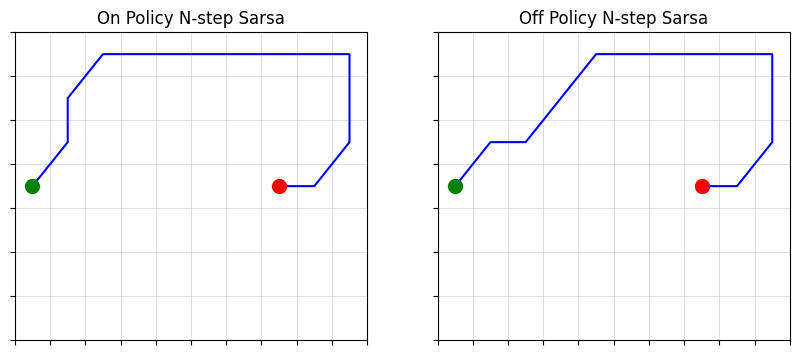

In [345]:
# plot gridworld and paths

# plot grid
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].set_title("On Policy N-step Sarsa")
axs[0].set_xlim(-0.5, env.x_max - 0.5)
axs[0].set_ylim(-0.5, env.y_max - 0.5)
axs[0].set_xticks(np.arange(-0.5, env.x_max, 1))
axs[0].set_yticks(np.arange(-0.5, env.y_max, 1))
axs[0].set_xticklabels([])
axs[0].set_yticklabels([])
axs[0].grid(True, which='both', color='lightgray', linewidth=0.5)
axs[0].plot([s[0] for s in path_on_policy], [s[1] for s in path_on_policy], 'b-', label='Path')
axs[0].plot(env.start_state[0], env.start_state[1], 'go', markersize=10, label='Start')
axs[0].plot(env.goal_state[0], env.goal_state[1], 'ro', markersize=10, label='Goal')
#
axs[1].set_title("Off Policy N-step Sarsa")
axs[1].set_xlim(-0.5, env.x_max - 0.5)
axs[1].set_ylim(-0.5, env.y_max - 0.5)
axs[1].set_xticks(np.arange(-0.5, env.x_max, 1))
axs[1].set_yticks(np.arange(-0.5, env.y_max, 1))
axs[1].set_xticklabels([])
axs[1].set_yticklabels([])
axs[1].grid(True, which='both', color='lightgray', linewidth=0.5)
axs[1].plot([s[0] for s in path_off_policy], [s[1] for s in path_off_policy], 'b-', label='Path')
axs[1].plot(env.start_state[0], env.start_state[1], 'go', markersize=10, label='Start')
axs[1].plot(env.goal_state[0], env.goal_state[1], 'ro', markersize=10, label='Goal')

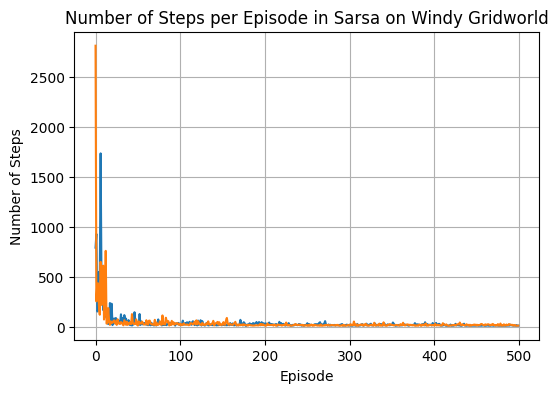

In [346]:
# plot number of steps per episode
plt.figure(figsize=(6, 4))
plt.plot(sarsa_on_policy.n_steps_per_episode)
plt.plot(sarsa_off_policy.n_steps_per_episode)
plt.xlabel('Episode')
plt.ylabel('Number of Steps')
plt.title('Number of Steps per Episode in Sarsa on Windy Gridworld')
plt.grid()
plt.show()